In [ ]:
# Mount Google Drive folder as a local folder
# Note: This mounts your entire drive, not the current folder
from google.colab import drive
drive.mount('/mydrive')

Mounted at /mydrive


In [ ]:
#TODO replace the path with your path in drive
#This usually takes 10 minutes to run
!cp -r /mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset ./

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential, Model

In [ ]:
# TRAIN_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/train/'
# TEST_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/test/'
TRAIN_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/train/'
TEST_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/test/'
SIZE = (224, 224)

In [ ]:
labels = []
for class_ in os.listdir(TRAIN_PATH):
    labels.append(class_)
NUM_LABELS = len(labels)

print(labels)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(rescale=1./255, validation_split = 0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

'''
Comments:
- ImageDataGenerator will resize all images to target_size
- x_col is the column where the images' names are
- y_col is the column where the labels are
- has_ext means that the images' names include a file extension, e.g. image_name.jpg
- Here you can change the targe_size to resize all images to different shapes.
Maybe larger images help in getting a better accuracy
'''
train_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TRAIN_PATH,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="training",
                                                 class_mode='categorical')

val_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TEST_PATH ,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="validation",
                                                 class_mode='categorical')

Found 9813 images belonging to 6 classes.
Found 268 images belonging to 6 classes.


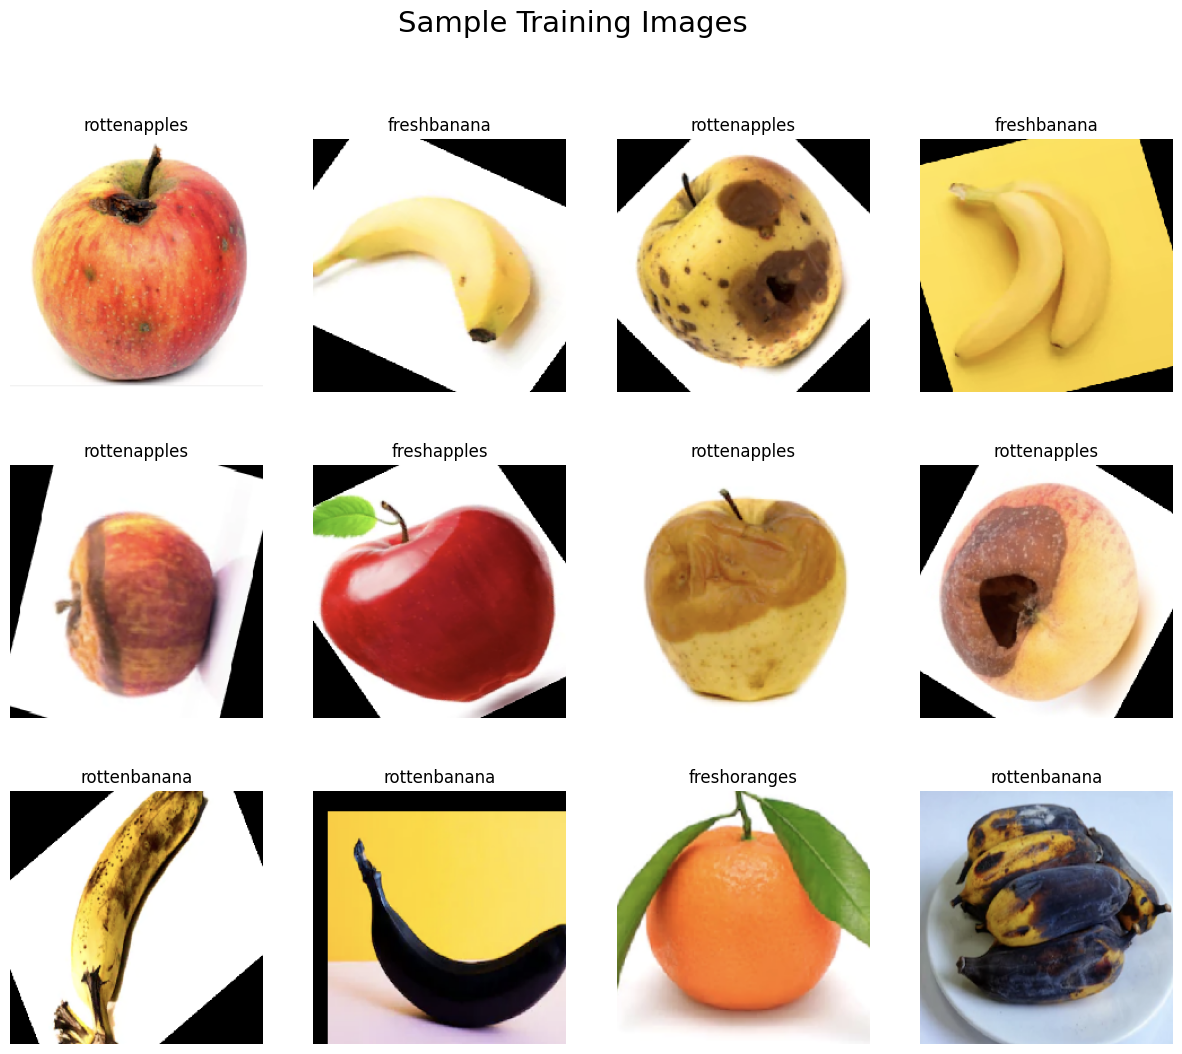

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(15, 12))
idx = 0

for i in range(3):
    for j in range(4):
        label = labels[np.argmax(train_dataset[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_dataset[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

# plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

In [ ]:
from keras.applications.densenet import DenseNet201

In [ ]:
from keras.models import Model
from keras.layers import Input, Dense
from tensorflow.keras.optimizers import  Adam


In [46]:
model = DenseNet201(
    include_top=True,
    weights=None,
    input_tensor=Input(shape=(224, 224, 3)),
    input_shape=None,
    pooling=None,
    classes=6,
)


In [47]:

from keras.callbacks import LearningRateScheduler

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import keras
from keras.layers import *
from keras.models import *
from keras.preprocessing import image
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [50]:
model.compile(loss='categorical_crossentropy',optimizer="adam",metrics=['accuracy'])
model.summary()
epochs = 30
stepsperepoch=187
validationsteps=1
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x)
es = EarlyStopping(monitor='val_acc', mode='max', verbose=1, patience=100)
mc = ModelCheckpoint("densenet201.h5", monitor='val_loss',save_best_only=True, mode='min',verbose=1)

Model: "densenet201"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,333,510 (69.94 MB)

 Trainable params: 18,104,454 (69.06 MB)

 Non-trainable params: 229,056 (894.75 KB)

In [51]:
hist = model.fit(
    train_dataset,
    epochs=epochs,
    callbacks=[annealer,mc,es],
    steps_per_epoch=stepsperepoch,
    validation_data=val_dataset,
    validation_steps = validationsteps
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1418']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.6951 - loss: 0.9178
Epoch 1: val_loss improved from inf to 11.13867, saving model to densenet201.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 418s 328ms/step - accuracy: 0.6955 - loss: 0.9165 - val_accuracy: 0.4375 - val_loss: 11.1387 - learning_rate: 0.0010
Epoch 2/30
  1/187 ━━━━━━━━━━━━━━━━━━━━ 28s 152ms/step - accuracy: 0.8125 - loss: 0.6340

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate
  current = self.get_monitor_value(logs)


...

187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 220ms/step - accuracy: 0.9715 - loss: 0.0778 - val_accuracy: 0.9062 - val_loss: 0.3111 - learning_rate: 4.8767e-04
Epoch 16/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - accuracy: 0.9717 - loss: 0.0755
Epoch 16: val_loss did not improve from 0.31111
187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step - accuracy: 0.9724 - loss: 0.0759 - val_accuracy: 0.5625 - val_loss: 2.9573 - learning_rate: 4.6329e-04
Epoch 17/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9760 - loss: 0.0720
Epoch 17: val_loss improved from 0.31111 to 0.06009, saving model to densenet201.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 217ms/step - accuracy: 0.9759 - loss: 0.0720 - val_accuracy: 0.9688 - val_loss: 0.0601 - learning_rate: 4.4013e-04
Epoch 18/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 14s 210ms/step - accuracy: 0.9724 - loss: 0.0743
Epoch 18: val_loss did not improve from 0.06009
187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 136ms/step - accuracy: 0.9733 - loss: 0.0731 - val_accuracy: 0.8125 - val_loss: 0.7811 - learning_rate: 4.1812e-04
Epoch 19/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9795 - loss: 0.0661
Epoch 19: val_loss improved from 0.06009 to 0.03208, saving model to densenet201.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 42s 224ms/step - accuracy: 0.9794 - loss: 0.0661 - val_accuracy: 0.9688 - val_loss: 0.0321 - learning_rate: 3.9721e-04
Epoch 20/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 13s 202ms/step - accuracy: 0.9795 - loss: 0.0576
Epoch 20: val_loss did not improve from 0.03208
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.9794 - loss: 0.0565 - val_accuracy: 0.6875 - val_loss: 1.4604 - learning_rate: 3.7735e-04
Epoch 21/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9861 - loss: 0.0468
Epoch 21: val_loss did not improve from 0.03208
187/187 ━━━━━━━━━━━━━━━━━━━━ 40s 211ms/step - accuracy: 0.9861 - loss: 0.0469 - val_accuracy: 0.9688 - val_loss: 0.0869 - learning_rate: 3.5849e-04
Epoch 22/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.9826 - loss: 0.0424
Epoch 22: val_loss did not improve from 0.03208
187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step - accuracy: 0.9821 - loss: 0.0452 - val_accuracy: 0.8125 - val_loss: 0.5606 - learning_rate: 3.4056

187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - accuracy: 0.9843 - loss: 0.0500 - val_accuracy: 1.0000 - val_loss: 0.0043 - learning_rate: 3.2353e-04
Epoch 24/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - accuracy: 0.9893 - loss: 0.0302
Epoch 24: val_loss did not improve from 0.00435
187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 138ms/step - accuracy: 0.9893 - loss: 0.0314 - val_accuracy: 0.8438 - val_loss: 0.4453 - learning_rate: 3.0736e-04
Epoch 25/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9873 - loss: 0.0377
Epoch 25: val_loss did not improve from 0.00435
187/187 ━━━━━━━━━━━━━━━━━━━━ 40s 212ms/step - accuracy: 0.9873 - loss: 0.0377 - val_accuracy: 1.0000 - val_loss: 0.0406 - learning_rate: 2.9199e-04
Epoch 26/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 13s 202ms/step - accuracy: 0.9888 - loss: 0.0362
Epoch 26: val_loss did not improve from 0.00435
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.9879 - loss: 0.0380 - val_accuracy: 0.7812 - val_loss: 1.4924 - learning_rate: 2.7739

187/187 ━━━━━━━━━━━━━━━━━━━━ 28s 148ms/step - accuracy: 0.9939 - loss: 0.0191 - val_accuracy: 1.0000 - val_loss: 8.0492e-05 - learning_rate: 2.2594e-04


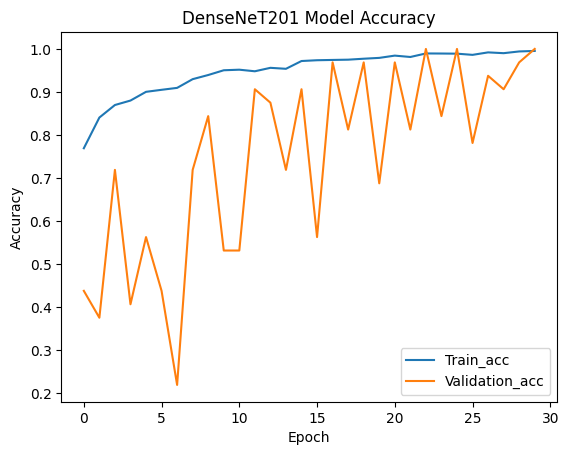

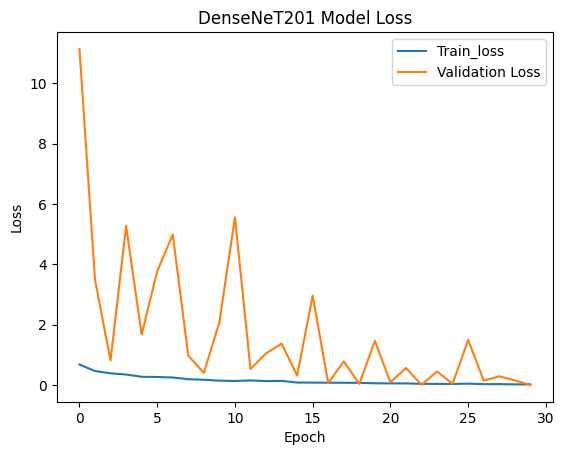

In [52]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('DenseNeT201 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(["Train_acc","Validation_acc"])
plt.show()

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('DenseNeT201 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(["Train_loss","Validation Loss"])
plt.show()

In [53]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(TEST_PATH,
                                                  batch_size=1,
                                                  target_size=SIZE,
                                                  shuffle = False,
                                                  classes=labels,
                                                  class_mode='categorical')


filenames = test_generator.filenames
nb_samples = len(filenames)

loss, acc = model.evaluate(test_generator,steps = (nb_samples), verbose=1)
print('accuracy test: ',acc)
print('loss test: ',loss)

Found 2698 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2698/2698 ━━━━━━━━━━━━━━━━━━━━ 70s 21ms/step - accuracy: 0.9977 - loss: 0.0079
accuracy test:  0.9970348477363586
loss test:  0.010174792259931564


In [ ]:
predictions = model.predict(test_generator)
files=test_generator.filenames
class_dict=test_generator.class_indices # a dictionary of the form class name: class index
rev_dict={}
for key, value in class_dict.items():
    rev_dict[value]=key

for i, p in enumerate(predictions):
    index=np.argmax(p)
    klass=rev_dict[index]
    prob=p[index]

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_709']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


2698/2698 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step


In [ ]:
print(len(test_generator[0][0]))
print(test_generator[0][1].shape)

1
(1, 6)


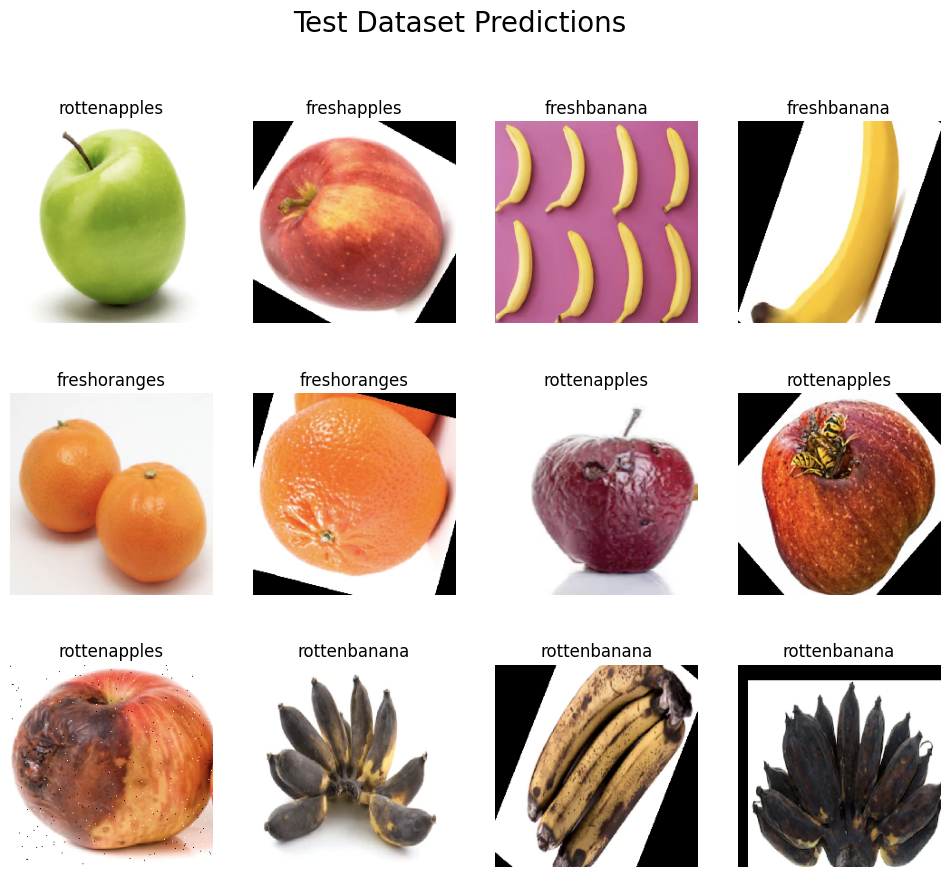

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(12, 10))
idx = 0

for i in range(3):
    for j in range(4):
        predicted_label = labels[np.argmax(predictions[idx])]
        ax[i, j].set_title(f"{predicted_label}")
        ax[i, j].imshow(test_generator[idx][0].reshape(224,224,3))
        ax[i, j].axis("off")
        idx += 200

# plt.tight_layout()
plt.suptitle("Test Dataset Predictions", fontsize=20)
plt.show()

In [ ]:
!apt install graphviz # Install graphviz (Only needed when in local runtime)
!pip install pydot # Install pydot as well (only when in local runtime)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [ ]:
#from keras.utils.vis_utils import plot_model
# tf.keras.utils.plot_model(
# model, to_file='model.png', show_shapes=True, show_dtype=False,
# show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
# )

# tf.keras.utils.plot_model(
#     model,
#     to_file="model.png",
#     show_shapes=True,
#     show_layer_names=True,
#     expand_nested=False,
#     dpi=72
# )

In [ ]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 18.0 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras import layers
from collections import defaultdict
# from PIL import ImageFont
# font = ImageFont.truetype("arial.ttf", 12)
color_map = defaultdict(dict) #customize the colours
color_map[layers.Conv2D]['fill'] = '#00f5d4'
color_map[layers.MaxPooling2D]['fill'] = '#8338ec'
color_map[layers.Dropout]['fill'] = '#03045e'
color_map[layers.Dense]['fill'] = '#fb5607'
color_map[layers.Flatten]['fill'] = '#ffbe0b'
# visualkeras.layered_view(model, legend=True,color_map=color_map,scale_xy=2, scale_z=1, max_z=200)

In [ ]:
test_steps_per_epoch = np.ceil(test_generator.samples / test_generator.batch_size)

# Convert test_steps_per_epoch to an integer
test_steps_per_epoch = int(test_steps_per_epoch)

In [ ]:
predictions = model.predict(test_generator, steps=test_steps_per_epoch)
# Get most likely class
predicted_classes = np.argmax(predictions, axis=1)

2698/2698 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step


In [ ]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

               precision    recall  f1-score   support

  freshapples       1.00      0.85      0.92       395
  freshbanana       0.93      0.99      0.96       381
 freshoranges       1.00      0.67      0.80       388
 rottenapples       0.91      0.99      0.95       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.77      0.98      0.86       403

     accuracy                           0.92      2698
    macro avg       0.94      0.91      0.92      2698
 weighted avg       0.94      0.92      0.92      2698



In [ ]:
print('Confusion Matrix')
# print(confusion_matrix(test_generator.classes, predicted_classes))
cm = confusion_matrix(test_generator.classes, predicted_classes)

Confusion Matrix


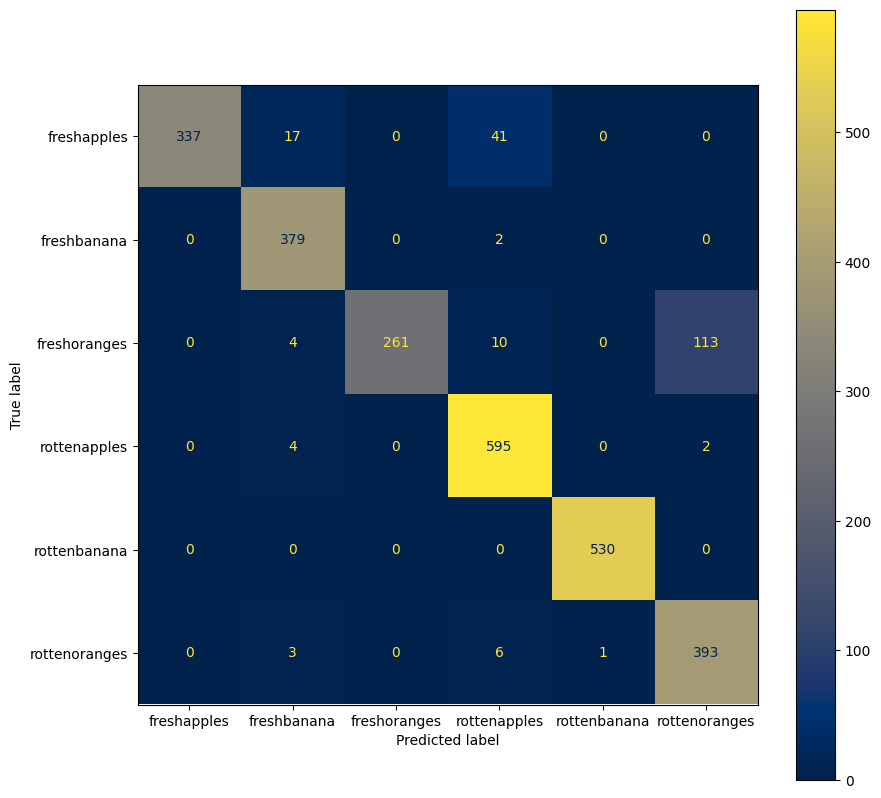

In [ ]:
w'w'wfrom sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_generator.classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap="cividis")